In [ ]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
from tqdm import tqdm
from tqdm.contrib.concurrent import process_map  # or thread_map
import umap
from scipy.optimize import linear_sum_assignment
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon, cosine, minkowski
from scipy.special import softmax
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from pyreadr import read_r
import multiprocessing as mp
from functools import partial
import random
from collections import defaultdict
import ipyvolume as ipv
import os
from heapq import heapify, heappop, heappush
from terminal_pareto import ParetoFront
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300



t_threshold = 250
ts_df = pd.read_csv("./data/embryo2/tracks.txt", sep="\t")
ts_df = ts_df.loc[ts_df["t"] <= t_threshold]
all_xyz_map = {}
cell_names = ts_df["name"].unique()
valid_cell_names = []
for name in cell_names:
    time_points = ts_df.loc[ts_df['name'] == name]["t"].values
    if len(time_points) == 1 and time_points[0] == t_threshold:
        continue
    all_xyz_map[name] = ts_df.loc[ts_df['name'] == name].values[-1][1:4]*0.1625
    valid_cell_names.append(name)

# name mapping
def map_names(did):
    """ Re-map cells to use their 'name' given their 'did'. Only applies to a
        few select cells where the tracker uses their 'name' instead of 'did'.
    """
    if   did == "P4a": return "Z3"
    elif did == "P4p": return "Z2"
    elif did == "P0a": return "AB"
    else: return did

if   EMBRYO==1: TSTOP=250

elif EMBRYO==2: TSTOP=242

elif EMBRYO==3: TSTOP=221

In [2]:
# lineage_exp = read_r("./data/viscello/lin_sc_expr_190602.rds")[None]
# lineage_exp = pd.read_csv("./data/protein/aggregated/lineage_adj_expression.csv", index_col=0)
# lineage_exp = pd.read_csv("./data/protein/aggregated/lineage_raw_expression.csv", index_col=0)
# lineage_exp = pd.read_csv("./data/protein/aggregated/lineage_umap_embedding.csv", index_col=0)
# lineage_exp = pd.read_csv("./data/protein/aggregated_all/binned_tenth_lineage_adj_expression.csv", index_col=0)
# lineage_exp = pd.read_csv("./data/protein/aggregated_all/binned_lineage_adj_exp_umap_embedding_3d.csv", index_col=0)
# lineage_exp = pd.read_csv("data/protein/aggregated_all/binned_lineage_adj_expression.csv", index_col=0)
# lineage_exp = pd.read_csv("./data/protein/aggregated_all/lineage_umap_embedding_s3.csv", index_col=0)
lineage_exp = pd.read_csv("./data/protein/aggregated_all/s3.csv", index_col=0).T
binary_lineage_exp = pd.read_csv("./data/protein/aggregated_all/lineage_binary_expression.csv", index_col=0)
binary_lineage_end_exp = pd.read_csv("./data/protein/aggregated_all/lineage_end_binary_expression.csv", index_col=0)
# fill nan with 0
lineage_exp = lineage_exp.fillna(0)

In [3]:
last_seen_time = defaultdict(int)
graph_by_time = defaultdict(dict) # time -> {cell_id: [neighbor_ids]}
for file in tqdm(os.listdir("data/nat_comm/MT_wee-1.1_1_GuiNeighbor/")):
    if file.endswith(".txt"):
        cur_time = int(file.split("_")[3])
        with open(os.path.join("data/nat_comm/MT_wee-1.1_1_GuiNeighbor/", file), 'r') as f:
            lines = f.readlines()
            for line in lines[1:]:
                cell_ids = [int(part) for part in line.strip().split(",")]
                cur_cell = cell_ids[0]
                neighbors = cell_ids[1:]
                graph_by_time[cur_time][cur_cell] = neighbors
                last_seen_time[cur_cell] = max(last_seen_time[cur_cell], cur_time)

  0%|          | 0/125 [00:00<?, ?it/s]

100%|██████████| 125/125 [00:00<00:00, 5012.98it/s]


In [4]:
neighbor_id_mapping = pd.read_csv("data/nat_comm/name_dictionary.csv", index_col=0).to_dict()

In [5]:
lineages_with_neighbors = set()
for id in last_seen_time.keys():
    lineages_with_neighbors.add(neighbor_id_mapping['name'][id])

In [6]:
# check number of positive values of each column
# lineage_exp_positive = lineage_exp.loc[:, (lineage_exp > 0).any(axis=0)]
# lineage_exp_positive_count = (lineage_exp_positive > 0).sum(axis=0)
# lineage_exp_positive_count.sort_values(ascending=True).head(20)

In [7]:
# tf filtering
# tf_df = pd.read_csv("./data/full_tf_names.tsv", sep="\t")
# tf_names = tf_df[~tf_df["Public name"].isna()]["Public name"].values
# tf_names_alt = tf_df["Sequence name"].values

In [8]:
# gene_name_df = pd.read_csv("./data/full_gene_names.tsv", sep="\t")
# valid_tf_names = []
# for name in gene_name_df['Gene'].values:
#     if name in tf_names or name in tf_names_alt:
#         valid_tf_names.append(name)

# # save to file for later use
# np.savetxt("./data/dropbox_valid_tf_names.txt", valid_tf_names, fmt="%s")


In [9]:
# expression data with only valid TFs
# lineage_exp = lineage_exp.loc[valid_tf_names]
lineage_names_with_exp = lineage_exp.columns.values
name_to_idx = {name: idx for idx, name in enumerate(lineage_exp.columns)}
expression_softmax = softmax(lineage_exp.values, axis=0)
lineage_softmax_exp = lineage_exp.copy()
lineage_softmax_exp.iloc[:,:] = expression_softmax

In [10]:
cell_type_df = pd.read_csv("data/2023-06-29_entropy_cell_key_V2.csv")
count = 0
lineage_type_dict = defaultdict(str)
for lineage in lineage_exp.columns:
    cur_cell_type_df = cell_type_df[cell_type_df['wormweb.lineage'] == lineage]
    if cur_cell_type_df.empty:
        # print(f"No cell types found for lineage: {lineage}")
        continue
    cur_lineage_types = cur_cell_type_df["wormweb.type"]
    # remove nan from cur_lineage_types
    cur_lineage_types = cur_lineage_types[~cur_lineage_types.isna()]
    cur_lineage_types = cur_lineage_types.unique()
    if len(cur_lineage_types) == 0:
        # print(f"No cell types found for lineage: {lineage}")
        continue
    lineage_type_dict[lineage] = cur_lineage_types[0]

In [11]:
import json

def load_json(file_path):
    """
    Load a JSON file and return its content as a Python object.
    
    :param file_path: Path to the JSON file.
    :return: Parsed JSON content as a Python object.
    """
    with open(file_path, 'r', encoding='utf-8') as file:
        return json.load(file)
    
lineage_data = load_json('./data/cell_lineage.json')


In [12]:
from collections import defaultdict
terminal_nodes = []
terminal_parents = []
terminal_parents_dict = defaultdict(list)
terminal_ancestry = defaultdict(list)
def dfs(node, parent, ancestors=[]):
    children = node.get("children", [])
    if len(children) == 0:
        lookup_name = map_names(node["did"])
        p_lookup_name = map_names(parent['did'])
        
        if lookup_name in valid_cell_names and lookup_name in lineage_names_with_exp and p_lookup_name in lineage_names_with_exp:
            terminal_nodes.append(lookup_name)
            terminal_parents.append(p_lookup_name)
            terminal_parents_dict[p_lookup_name].append(lookup_name)
            terminal_ancestry[len(terminal_nodes)-1] = ancestors
    else:
        for child in children:
            dfs(child, node, ancestors + [node["did"]])

dfs(lineage_data, None)

In [13]:
def terminal_cousin_group(terminal_ancestry, degree=2):
    lowest_common_ancestor_group = defaultdict(list)
    for terminal_name, ancestry in terminal_ancestry.items():
        if len(ancestry) < degree:
            continue
        lca = ancestry[-degree]
        lowest_common_ancestor_group[lca].append(terminal_name)
    return lowest_common_ancestor_group

In [14]:
terminal_node_cords = []
terminal_parent_cords = []
xyz_coord_dict = {}
exp_vector_dict = {}
# Collect coordinates for terminal nodes and their parents

for node, parent in zip(terminal_nodes, terminal_parents):
    xyz_coord_dict[node] = ts_df.loc[ts_df['name'] == node].values[-1][1:4]*0.1625
    xyz_coord_dict[parent] = ts_df.loc[ts_df['name'] == parent].values[-1][1:4]*0.1625
    exp_vector_dict[node] = lineage_exp.loc[:, node].values
    exp_vector_dict[parent] = lineage_exp.loc[:, parent].values

In [15]:
new_pf = ParetoFront(terminal_nodes, terminal_parents, terminal_ancestry, ts_df, lineage_exp, binary_lineage_exp, binary_lineage_end_exp, title="t=280, Pareto Front of 476 Terminal Cells")

100%|██████████| 476/476 [00:02<00:00, 191.57it/s]


Monte Carlo Simulation:   0%|          | 0/10000 [00:00<?, ?it/s]

Monte Carlo Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]

1657.0239720382438


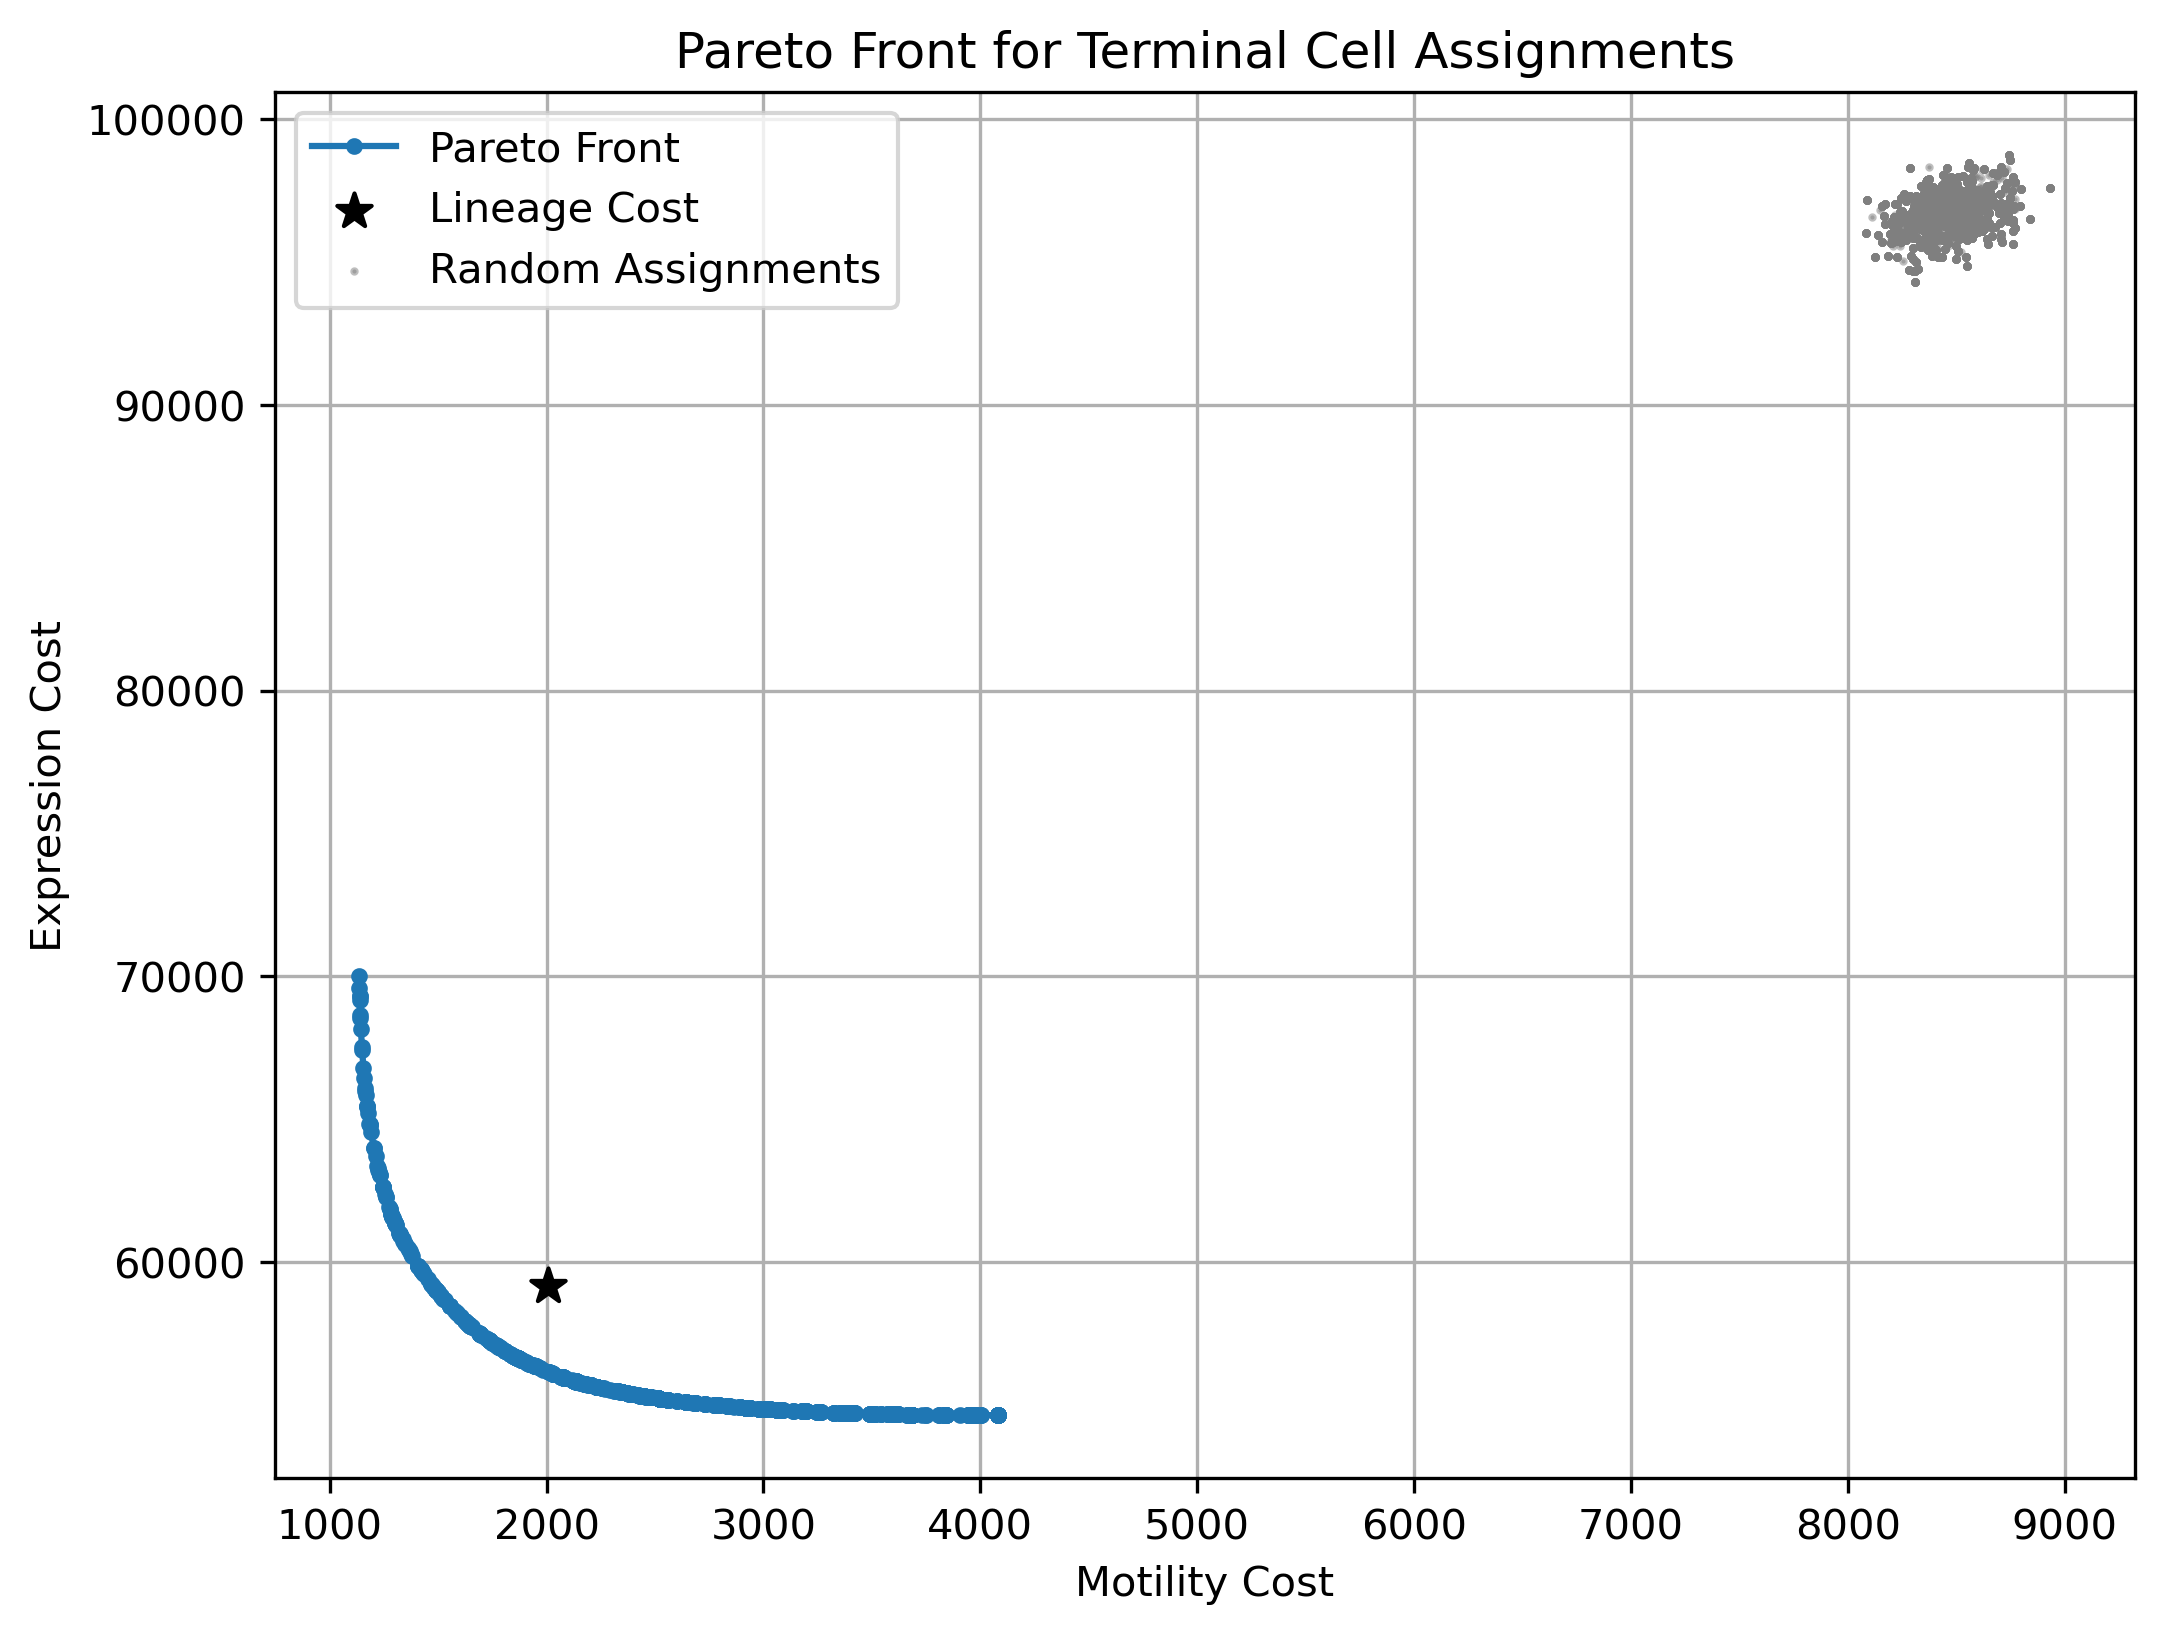

In [16]:
res = new_pf.pre_plot()

In [30]:
monte_carlo_list, pareto_xyz_cost_list, pareto_exp_cost_list, lineage_xyz_cost, lineage_exp_cost = res

In [34]:
monte_carlo_xyz_cost = [item[0] for item in monte_carlo_list]
monte_carlo_exp_cost = [item[1] for item in monte_carlo_list]
monte_carlo_xyz_mean = np.mean(monte_carlo_xyz_cost)
monte_carlo_exp_mean = np.mean(monte_carlo_exp_cost)
monte_carlo_xyz_std = np.std(monte_carlo_xyz_cost)
monte_carlo_exp_std = np.std(monte_carlo_exp_cost)

print((monte_carlo_xyz_mean - lineage_xyz_cost) / monte_carlo_xyz_std, (monte_carlo_exp_mean - lineage_exp_cost) / monte_carlo_exp_std)
print((monte_carlo_xyz_mean - np.min(pareto_xyz_cost_list)) / monte_carlo_xyz_std, (monte_carlo_exp_mean - np.min(pareto_exp_cost_list)) / monte_carlo_exp_std)


43.730214517960704 50.18799286493368
49.61225039266454 56.22062423232257


In [36]:
from scipy.stats import norm
norm.cdf(40)

np.float64(1.0)

100%|██████████| 248/248 [00:00<00:00, 267.58it/s]



Computing cost matrices with expression norm: L1


<string>:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


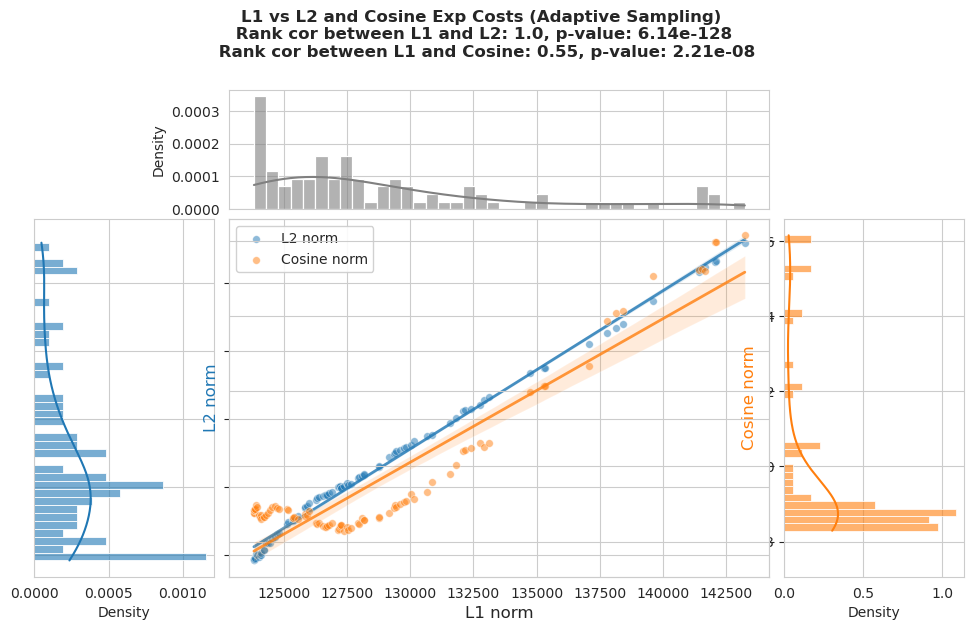

unique number of L1 cost values: 89
Computing cost matrices with expression norm: L2


<string>:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


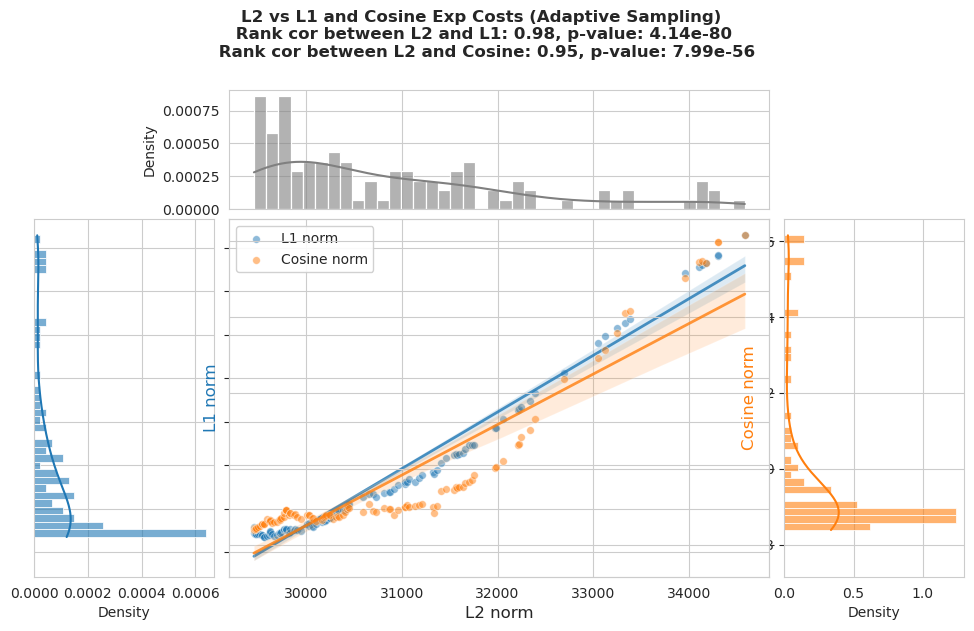

unique number of L2 cost values: 108
Computing cost matrices with expression norm: Cosine


<string>:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


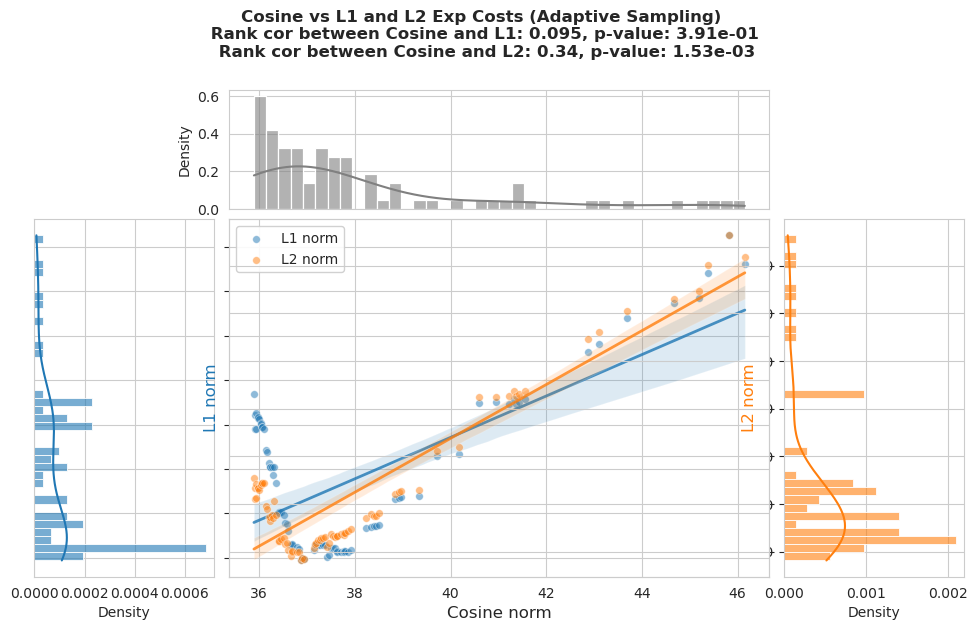

unique number of Cosine cost values: 84


In [45]:
res = new_pf.norm_comp_with_adaptive_sampling()

100%|██████████| 248/248 [00:00<00:00, 266.34it/s]



Computing cost matrices with expression norm: l1


<string>:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


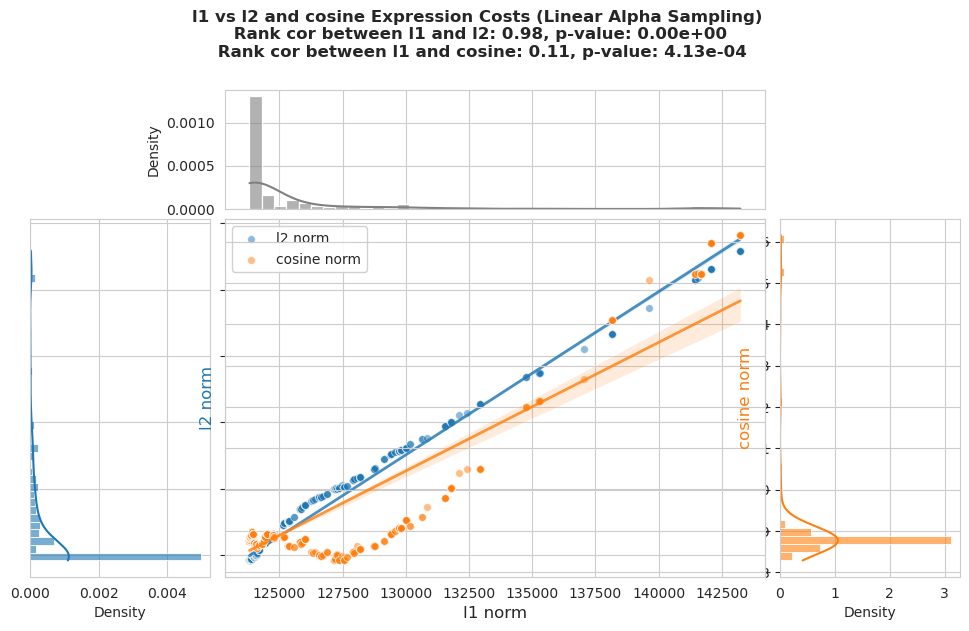

unique number of l1 cost values: 142
Computing cost matrices with expression norm: l2


<string>:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


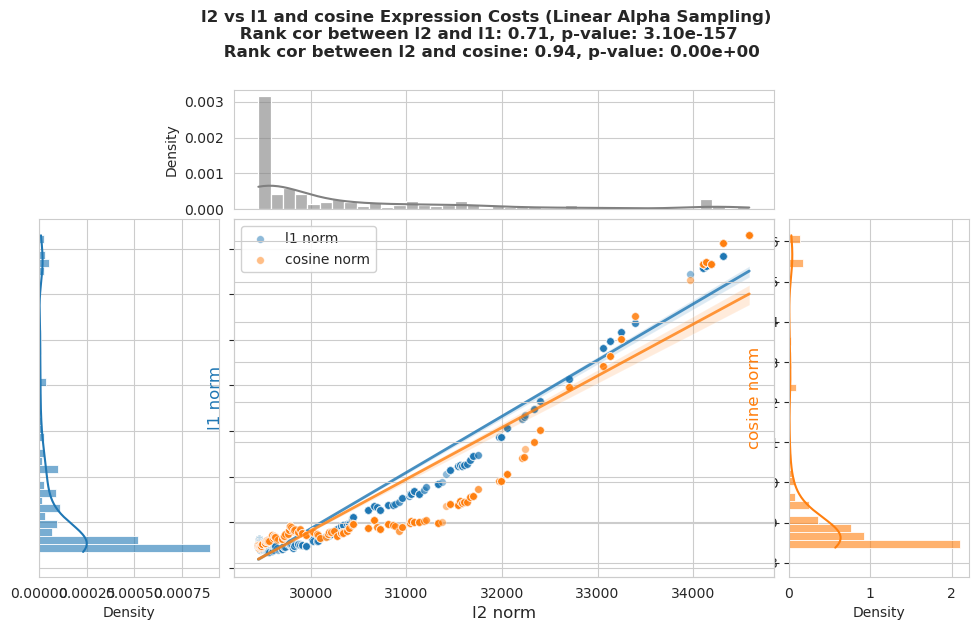

unique number of l2 cost values: 201
Computing cost matrices with expression norm: cosine


<string>:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


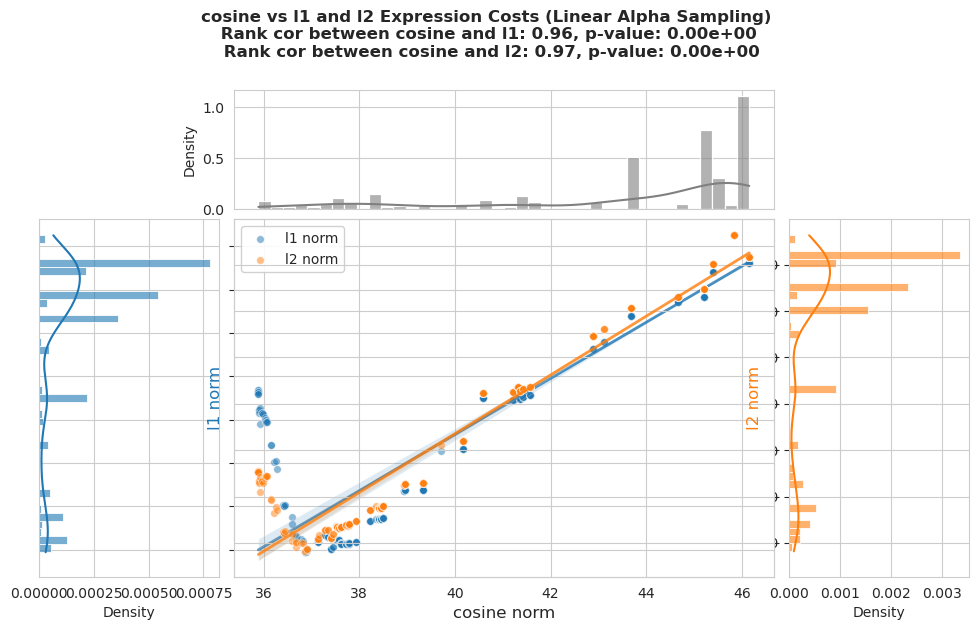

unique number of cosine cost values: 101


In [46]:
l2_cost_list, cosine_cost_list = new_pf.norm_comp()

In [ ]:
from scipy.spatial import KDTree

In [ ]:
kd_tree = KDTree(lineage_exp.T)


In [57]:
lineage_exp.sum()

cell
ABa        123.10
ABal       370.06
ABala      395.98
ABalaa     414.86
ABalaaa    710.05
            ...  
P2         317.11
P3         361.52
P4         289.33
Z2         302.14
Z3         318.65
Length: 1204, dtype: float64

In [50]:
kd_tree.query(np.zeros(291))

(46.53861622351915, np.int64(862))

In [52]:
x, y = np.mgrid[0:5, 2:8]
tree = KDTree(np.c_[x.ravel(), y.ravel()])
dd, ii = tree.query([[0, 0], [2.2, 2.9]], k=1)
print(dd, ii)

[2.        0.2236068] [ 0 13]


Computing cost matrices with norm: l1


100%|██████████| 248/248 [00:00<00:00, 325.94it/s]


Monte Carlo Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]

950.4625000000001


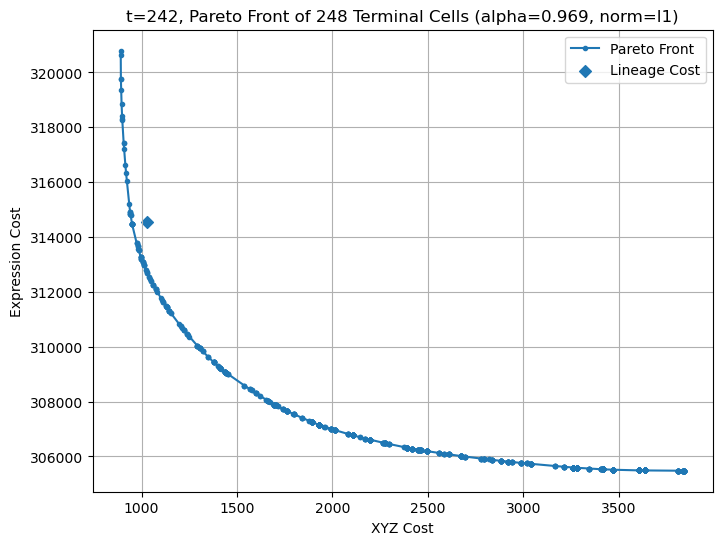

Computing cost matrices with norm: l2


100%|██████████| 248/248 [00:00<00:00, 408.43it/s]


Monte Carlo Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]

633.6002680687883


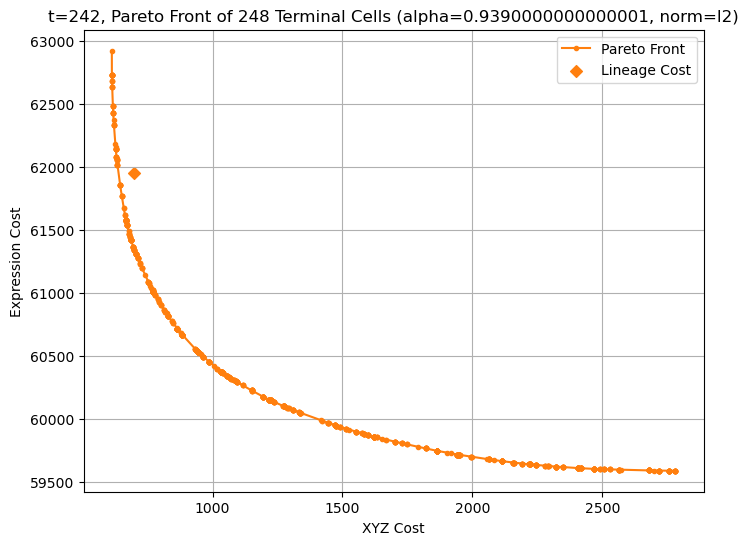

Computing cost matrices with norm: cosine


100%|██████████| 248/248 [00:00<00:00, 279.66it/s]


Monte Carlo Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]

0.234885013741023


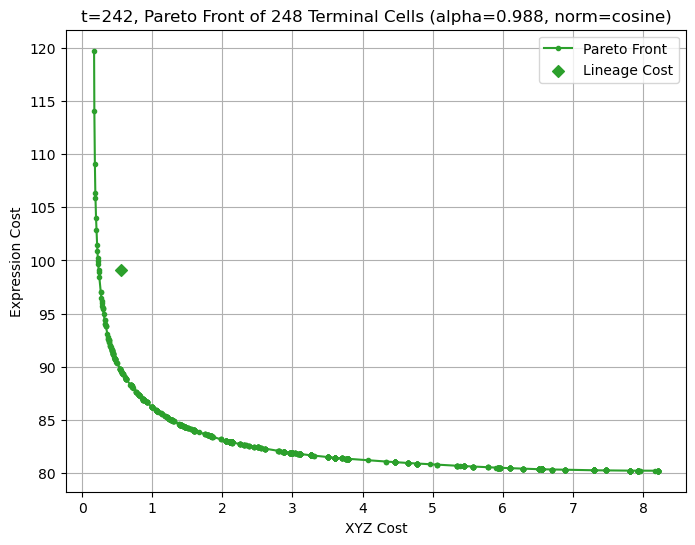

Computing cost matrices with norm: l2+cosine


100%|██████████| 248/248 [00:00<00:00, 344.07it/s]


Monte Carlo Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]

646.477105189015


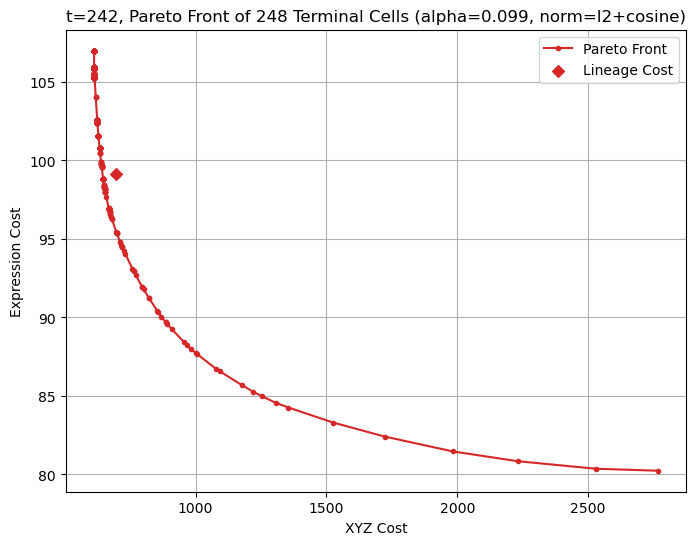

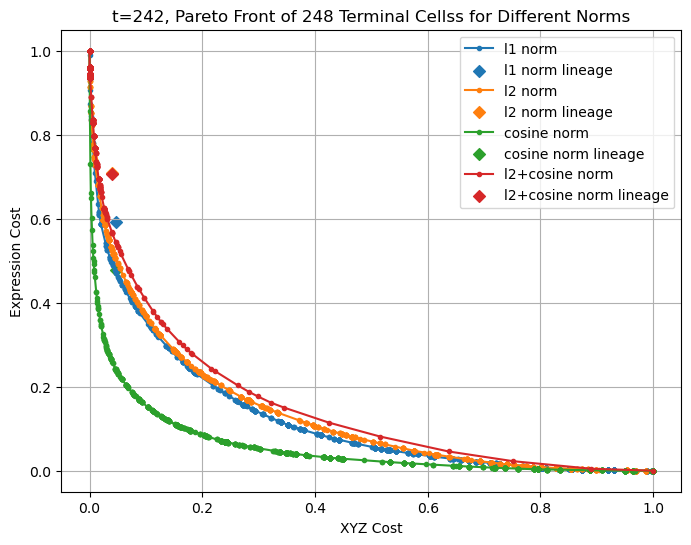

In [181]:
new_pf.normal_run()

In [23]:
sns.color_palette(n_colors=3)

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313)]

In [ ]:
def terminal_trajectory(terminal_node):
    ''' 
    using ipyvolume plot the lineage trajectory with directed arrow a terminal node in 3d plot
    the first few ancestors in each terminal's lineage may not have physical coordinates
    start from the first ancestor with physical coordinates
    '''
    if terminal_node not in terminal_nodes:
        print(f"Terminal node {terminal_node} not found in terminal nodes.")
        return
    ancestors = terminal_ancestry[terminal_nodes.index(terminal_node)]
    coordinates = []
    for ancestor in ancestors:
        if ancestor in all_xyz_map:
            coordinates.append(all_xyz_map[ancestor])
    if not coordinates:
        print(f"No physical coordinates found for ancestors of terminal node {terminal_node}.")
        return
    coordinates = np.array(coordinates)
    return coordinates

temp_coordinates = terminal_trajectory("ABprpppapaa").astype(float)
fig = ipv.figure()
x, y, z = temp_coordinates[:, 0], temp_coordinates[:, 1], temp_coordinates[:, 2]
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
z_min, z_max = z.min(), z.max()
ipv.xlim(x_min, x_max)
ipv.ylim(y_min, y_max)
ipv.zlim(z_min, z_max)
dx = np.diff(temp_coordinates[:, 0])
dy = np.diff(temp_coordinates[:, 1])
dz = np.diff(temp_coordinates[:, 2])
ipv.quiver(temp_coordinates[:-1, 0], temp_coordinates[:-1, 1], temp_coordinates[:-1, 2], dx, dy, dz, 
          color='red', arrow_length_ratio=0.1, size=10)
ipv.plot(x, y, z, marker='o', linestyle='-', color='blue', size=2)
ipv.show()

In [ ]:
# for every terminal node, plot the trajectory
# save the plot to output/xyz_trajectories/{node_name}.png
import os
output_dir = "output/xyz_trajectories"
os.makedirs(output_dir, exist_ok=True)
for terminal_node in tqdm(terminal_nodes):
    fig = terminal_trajectory(terminal_node)
    if fig:
        fig.savefig(os.path.join(output_dir, f"{terminal_node}.png"))
        plt.close(fig)  # Close the figure to free memory


In [ ]:
pair_count = 0
diff_type_count = 0
for parent, children in terminal_parents_dict.items():
    if len(children) > 1:
        pair_count += 1
        type_0 = lineage_type_dict[children[0]]
        type_1 = lineage_type_dict[children[1]]
        if type_0 != type_1:
            diff_type_count += 1

for node in terminal_nodes:
    if len(lineage_type_dict[node]) == 0:
        print(f"Node {node} has no lineage type.")
```